In [34]:
from villas.dataprocessing.readtools import *
from villas.dataprocessing.timeseries import *
from villas.dataprocessing.timeseries import TimeSeries as ts
import matplotlib.pyplot as plt
import numpy as np
import dpsimpy
import re

#%matplotlib widget

epsilon = 1e-12

In [35]:
# Nodes
gnd = dpsimpy.emt.SimNode.gnd
n0  = dpsimpy.emt.SimNode("n0")


v_s = dpsimpy.emt.ph1.VoltageSource("v_s")
v_s.set_parameters(-100j, 50)

r = dpsimpy.emt.ph1.Resistor("r")
r.R = 100


# Connections 
v_s.connect([gnd, n0])
r.connect([n0, gnd])


In [36]:
sys = dpsimpy.SystemTopology(50, [ n0 ], [ v_s, r ])

In [37]:
sim = dpsimpy.Simulation("VoltageSource", loglevel=dpsimpy.LogLevel.debug)
sim.set_system(sys)
sim.set_domain(dpsimpy.Domain.EMT)
sim.set_time_step(0.0001)
sim.set_final_time(0.05)

log = dpsimpy.Logger("VoltageSource")
for i in range(0, len(sys.nodes)):
    log.log_attribute("v" + str(i), "v", sys.nodes[i])

sim.add_logger(log)
    
sim.run()

[15:08:21.836649 VoltageSource info] Initialize simulation: VoltageSource
[15:08:21.843837 MnaSolverFactory info] creating KLUAdapter solver implementation
[15:08:21.873985 VoltageSource info] Scheduling tasks.
[15:08:21.885669 VoltageSource info] Scheduling done.
[15:08:21.885686 VoltageSource info] Opening interfaces.
[15:08:21.885689 VoltageSource info] Start synchronization with remotes on interfaces
[15:08:21.885691 VoltageSource info] Synchronized simulation start with remotes
[15:08:21.885694 VoltageSource info] Start simulation: VoltageSource
[15:08:21.885701 VoltageSource info] Time step: 1.000000e-04
[15:08:21.885705 VoltageSource info] Final time: 5.000000e-02
[15:08:21.889966 VoltageSource info] Simulation calculation time: 0.004204
[15:08:21.905296 VoltageSource info] Simulation finished.


column number: 1
results length: 501
real column names: ['v0']
complex column names: []


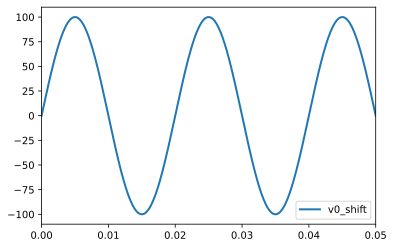

In [38]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
%config InlineBackend.rc = {'font.size': 10, 'figure.figsize': (6.0, 4.0), 'figure.facecolor': 'white', 'savefig.dpi': 72, 'figure.subplot.bottom': 0.125, 'figure.edgecolor': 'white'}

import matplotlib.pyplot as plt
import villas.dataprocessing.plottools as pt
import villas.dataprocessing.readtools as rt
import villas.dataprocessing.timeseries as ts

results     = rt.read_timeseries_dpsim('logs/VoltageSource.csv')
results_emt = [ results[series].frequency_shift(freq=0) for series in results ]

#for series in results_emt:
    #pt.plot_timeseries('Results EMT', series)
pt.plot_timeseries('Results EMT', results_emt[0])
plt.show()